# Path Classification

In [32]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from scipy.ndimage import median_filter
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from mhealth_activity import Recording

TRAIN_DIR = Path('data/train')
train_files = sorted(TRAIN_DIR.glob('*.pkl'))

def clean_altitude(values, timestamps, max_jump=5.0, smooth_window=5):
    mask = np.ones(len(values), dtype=bool)
    last_valid = values[0]
    for i in range(1, len(values)):
        if abs(values[i] - last_valid) > max_jump:
            mask[i] = False
        else:
            last_valid = values[i]
    return median_filter(values[mask], size=smooth_window), timestamps[mask]

def extract_sensor_features(values, timestamps, prefix):
    slope, _ = np.polyfit(timestamps, values, 1)

    # Half-split slopes
    mid = len(values) // 2
    slope_first,  _ = np.polyfit(timestamps[:mid], values[:mid], 1)
    slope_second, _ = np.polyfit(timestamps[mid:], values[mid:], 1)

    # Scan for flattest segment using a sliding window (10% of recording)
    win = max(3, len(values) // 10)
    local_slopes = [
        abs(np.polyfit(timestamps[i:i+win], values[i:i+win], 1)[0])
        for i in range(len(values) - win)
    ]
    min_local_slope = min(local_slopes)
    # When (relative time) does the flattest segment occur?
    flattest_pos = np.argmin(local_slopes) / len(local_slopes)

    return {
        f'{prefix}_start':        values[0],
        f'{prefix}_end':          values[-1],
        f'{prefix}_delta':        values[-1] - values[0],
        f'{prefix}_range':        values.max() - values.min(),
        f'{prefix}_mean':         values.mean(),
        f'{prefix}_slope':        slope,
        f'{prefix}_slope_first':  slope_first,
        f'{prefix}_slope_second': slope_second,
        f'{prefix}_slope_diff':   slope_second - slope_first,
        f'{prefix}_min_local_slope':  min_local_slope,
        f'{prefix}_flattest_pos': flattest_pos,
    }

def extract_features(rec):
    features = {}
    features['duration'] = rec.data['ax'].total_time

    pressure_keys = ['pressure_start','pressure_end','pressure_delta','pressure_range',
                     'pressure_mean','pressure_slope','pressure_slope_first',
                     'pressure_slope_second','pressure_slope_diff',
                     'pressure_min_local_slope','pressure_flattest_pos']
    altitude_keys = [k.replace('pressure', 'altitude') for k in pressure_keys]

    if 'phone_pressure' in rec.data:
        p = rec.data['phone_pressure']
        features.update(extract_sensor_features(p.values, p.timestamps, 'pressure'))
        features['has_pressure'] = 1
    else:
        for k in pressure_keys:
            features[k] = np.nan
        features['has_pressure'] = 0

    if 'altitude' in rec.data:
        a = rec.data['altitude']
        cleaned, ts_clean = clean_altitude(a.values, a.timestamps)
        if len(cleaned) > 1:
            features.update(extract_sensor_features(cleaned, ts_clean, 'altitude'))
        features['has_altitude'] = 1
    else:
        for k in altitude_keys:
            features[k] = np.nan
        features['has_altitude'] = 0

    return features

# Load & cache features

In [33]:
FEATURES_CACHE = 'data/path_features.csv'

if os.path.exists(FEATURES_CACHE):
    X = pd.read_csv(FEATURES_CACHE, index_col=0)
    labels = X.pop('label').values
    print(f"Loaded from cache ({len(X)} recordings)")
else:
    all_features, all_labels = [], []
    for f in train_files:
        r = Recording(str(f))
        all_labels.append(r.labels['path_idx'])
        all_features.append(extract_features(r))
    X = pd.DataFrame(all_features)
    labels = np.array(all_labels)
    X['label'] = labels
    X.to_csv(FEATURES_CACHE)
    X.pop('label')
    print(f"Extracted and cached features ({len(X)} recordings)")

y = labels
print(X.shape)
print(f"NaNs:\n{X.isna().sum()}")
X.head()

Loaded from cache (396 recordings)
(396, 25)
NaNs:
duration                     0
pressure_start              67
pressure_end                67
pressure_delta              67
pressure_range              67
pressure_mean               67
pressure_slope              67
pressure_slope_first        67
pressure_slope_second       67
pressure_slope_diff         67
pressure_min_local_slope    67
pressure_flattest_pos       67
has_pressure                 0
altitude_start               2
altitude_end                 2
altitude_delta               2
altitude_range               2
altitude_mean                2
altitude_slope               2
altitude_slope_first         2
altitude_slope_second        2
altitude_slope_diff          2
altitude_min_local_slope     2
altitude_flattest_pos        2
has_altitude                 0
dtype: int64


,duration,pressure_start,pressure_end,pressure_delta,pressure_range,pressure_mean,pressure_slope,pressure_slope_first,pressure_slope_second,pressure_slope_diff,...,altitude_delta,altitude_range,altitude_mean,altitude_slope,altitude_slope_first,altitude_slope_second,altitude_slope_diff,altitude_min_local_slope,altitude_flattest_pos,has_altitude
0,576.042,963.478760,958.407500,-5.071260,5.322020,960.670023,-0.010496,-0.011084,-0.008403,0.002681,...,40.700012,42.741807,480.092365,0.085283,0.098881,0.063239,-0.035641,4.330434e-17,0.892746,1
1,788.925,962.975830,957.957092,-5.018738,5.112610,960.045776,-0.007052,-0.008200,-0.005476,0.002724,...,41.644166,48.486883,433.986814,0.061966,0.065577,0.042611,-0.022966,1.679381e-05,0.219262,1
2,540.746,968.725600,963.394800,-5.330800,5.477300,965.654004,-0.011146,-0.012231,-0.008469,0.003762,...,41.109425,44.439322,481.104377,0.086348,0.102078,0.060668,-0.041410,2.285867e-05,0.958114,1
3,733.139,962.800598,957.283081,-5.517517,5.626770,959.911169,-0.009025,-0.009453,-0.007352,0.002101,...,42.904495,45.122381,429.805096,0.073853,0.076784,0.050869,-0.025914,9.810672e-03,0.999877,1
4,530.442,962.902954,968.114685,5.211731,5.233521,965.874882,0.012250,0.015605,0.007496,-0.008109,...,-42.292610,46.120132,425.906652,-0.097913,-0.131935,-0.061680,0.070255,2.384878e-05,0.522155,1


# Explore: pressure & altitude per path

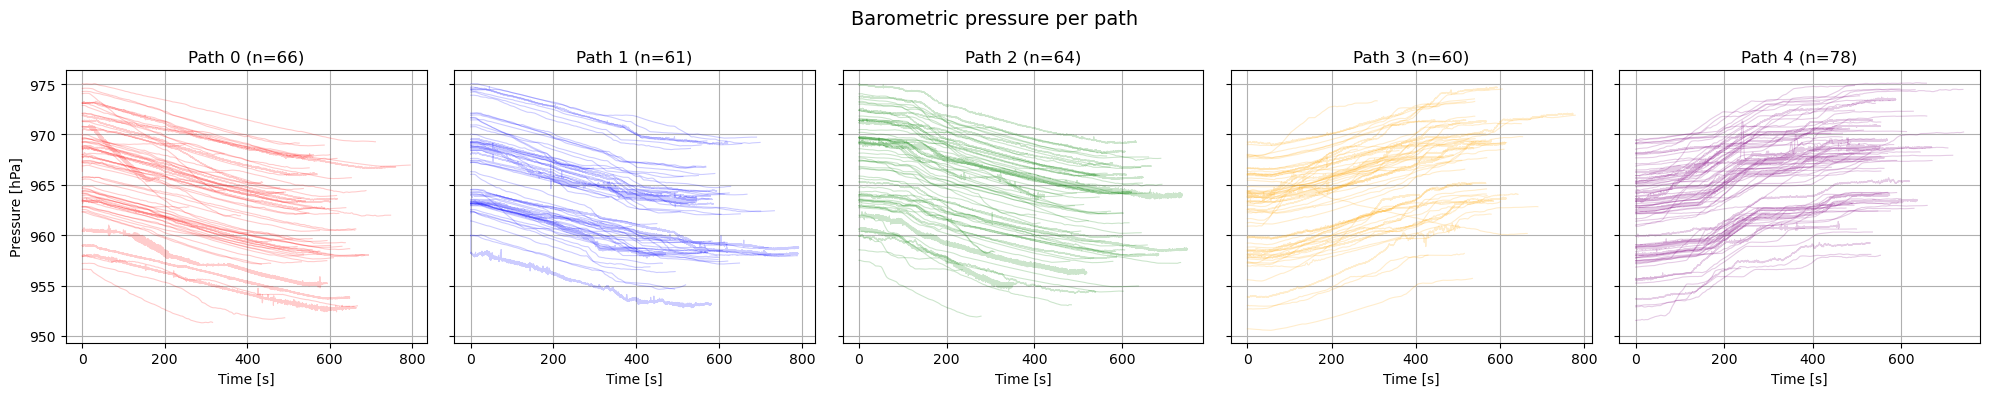

In [34]:
# Load one recording per path for visualization (fast — only 5 files)
df_meta = pd.DataFrame({'file': [f.name for f in train_files], 'label': labels})
colors = ['red', 'blue', 'green', 'orange', 'purple']

fig, axes = plt.subplots(1, 5, figsize=(20, 4), sharey=True)
for path_idx in range(5):
    ax = axes[path_idx]
    subset = df_meta[df_meta.label == path_idx]
    count = 0
    for fname in subset['file']:
        rec = Recording(str(TRAIN_DIR / fname))
        if 'phone_pressure' not in rec.data:
            continue
        p = rec.data['phone_pressure']
        ax.plot(p.timestamps, p.values, color=colors[path_idx], alpha=0.2, linewidth=0.8)
        count += 1
    ax.set_title(f'Path {path_idx} (n={count})')
    ax.set_xlabel('Time [s]')
    ax.grid(True)
axes[0].set_ylabel('Pressure [hPa]')
plt.suptitle('Barometric pressure per path', fontsize=14)
plt.tight_layout()
plt.show()

# Train / test split

In [36]:
X_train, X_test, y_train, y_test = train_test_split(
    X, labels, test_size=0.2, random_state=42, stratify=labels
)
print(f"Train: {len(X_train)}  Test: {len(X_test)}")

Train: 316  Test: 80


# Train & evaluate

              precision    recall  f1-score   support

      Path 0       0.62      0.59      0.61        17
      Path 1       0.67      0.67      0.67        15
      Path 2       0.88      0.93      0.90        15
      Path 3       1.00      0.93      0.96        14
      Path 4       0.95      1.00      0.97        19

    accuracy                           0.82        80
   macro avg       0.82      0.82      0.82        80
weighted avg       0.82      0.82      0.82        80



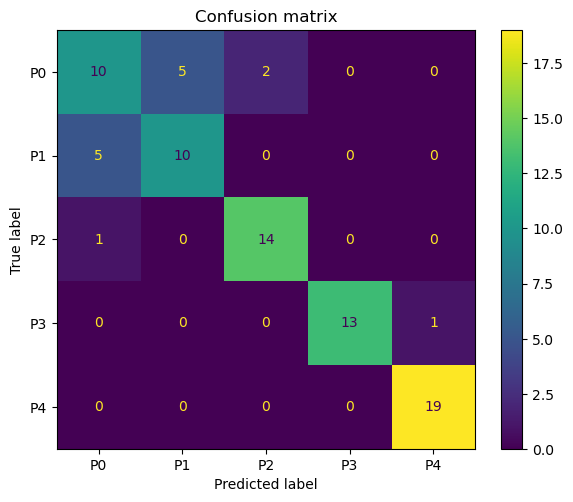

In [37]:
model = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42)),
])

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred, target_names=[f'Path {i}' for i in range(5)]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=[f'P{i}' for i in range(5)]).plot(ax=ax)
plt.title('Confusion matrix')
plt.tight_layout()
plt.show()

# Feature importances

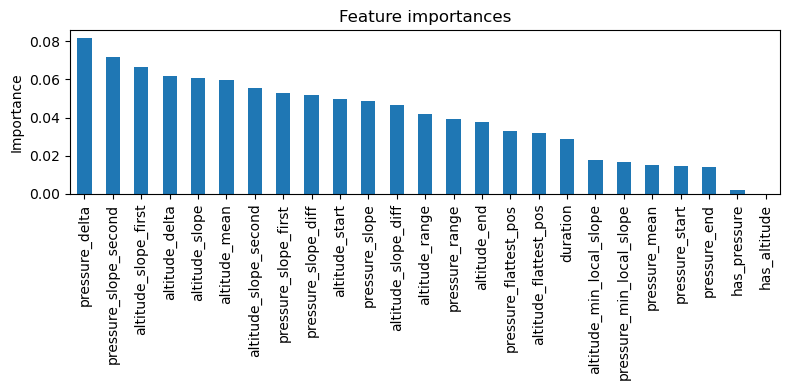

In [38]:
importances = model.named_steps['clf'].feature_importances_
feat_df = pd.Series(importances, index=X.columns).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
feat_df.plot(kind='bar', ax=ax)
ax.set_title('Feature importances')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.show()